# DeepSeek Extension: Stage 1-8 Cross-Country Predictions

**Purpose.** Adds DeepSeek (a non-Western-developed frontier model) to the Stage 1-8 information-addition design used for GPT-4o mini, Claude 3.5 Haiku, Gemini 2.5 Flash, and Llama 4 Maverick in the main study. Responds to the editor's point 4 ("what differences might emerge if using LLMs developed in other countries?") and Reviewer 3's citation of Wang et al. (2025) on training-provenance effects on cultural representation.

**Scope decision (see chat discussion):** this notebook runs the same 8-stage design as the four incumbent models — it does **not** replicate the feature-ablation, counterfactual, or memorization-battery diagnostics. That keeps this addition proportionate: Stage 1-8 gives the headline MAE/r comparison at full information (Stage 8) plus the staged trajectory, which is what the "does training origin matter" question actually needs answered. Frame in the manuscript as exploratory/post-hoc, the same register as the 24-item U.S. policy generalization test.

**⚠️ Before running at scale — read this.** The eight `build_prompt_stageN()` functions below are reconstructed from the original study's prompt-generation script. Stages 1, 6, 7, and 8 are reproduced verbatim (I have exact saved text for these). Stages 2-5 (single information-block conditions) follow the same template but the connector phrase ("Based on the country and X, estimate...") is inferred by extension of the confirmed pattern rather than copy-pasted from a saved original. **If you still have `2_LLM_INFERENCE_COUNTRY.py` (or equivalent) saved, diff Stages 2-5 against it before running** — a wording mismatch there wouldn't bias Stage 8 (the headline number) but would weaken the staged-trajectory comparison. The Section 1 smoke test below prints all 8 prompts for one country so you can eyeball them first.

**Required files in the working directory:**
- `data_final.csv` — ground truth + covariates (same file as the main pipeline)
- `predictions_all_stages_long.csv` — optional, only needed for Section 5 onward (the four-model comparison/figure). Section 1-4 (prompt building + DeepSeek API calls) run without it.

**Output:** `deepseek_predictions_all_stages.csv`, in the same schema as the main pipeline (`stage`, `countrynew`, `pred_deepseek`), so it can be merged directly into `predictions_all_stages_long.csv` for the main analysis notebook, plus SM figure/table CSVs matching the Fig. S2/S3 style.

## 0. Setup

In [1]:
import os
import time
import json as _json
import pandas as pd
import numpy as np
import matplotlib
matplotlib.rcParams.update({'font.size': 11})
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, kendalltau

# DeepSeek uses an OpenAI-compatible API
try:
    from openai import OpenAI
except ImportError:
    %pip install openai --quiet
    from openai import OpenAI

DEEPSEEK_API_KEY = os.environ.get("DEEPSEEK_API_KEY", "")
print("DEEPSEEK_API_KEY:", "\u2713 set" if DEEPSEEK_API_KEY else "\u2717 MISSING \u2014 set this in Deepnote's environment variables before running Section 3")

DEEPSEEK_MODEL = "deepseek-chat"   # DeepSeek-V3.1 as of the API's default chat model; matches "DeepSeek V3" used in the companion cross-linguistic study
deepseek_client = OpenAI(api_key=DEEPSEEK_API_KEY, base_url="https://api.deepseek.com/v1")

CHECKPOINT_FILE = "deepseek_predictions_all_stages.csv"
N_STAGES = 8


DEEPSEEK_API_KEY: ✓ set


## 1. Load data and build the 8 staged prompts

Reuses `data_final.csv` exactly as in the main pipeline. The formatting helpers (`fmt_pct`, `fmt_num`) and the `OWN_LESS_COL` / `TEMP_COL` name-detection guard against the two known column-naming variants in this dataset.

In [3]:
df = pd.read_csv("data_final.csv")

def as_pct(x):
    """Accept 0-1 or 0-100 and return a 0-100 percentage."""
    if pd.isna(x):
        return None
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v * 100.0 if 0 <= v <= 1 else v

def as_num(x, nd=1):
    if pd.isna(x):
        return None
    try:
        return round(float(x), nd)
    except (TypeError, ValueError):
        return None

def fmt_pct(x):
    v = as_pct(x)
    return f"{v:.1f}%" if v is not None else "N/A"

def fmt_num(x, nd=1):
    v = as_num(x, nd)
    return f"{v:.{nd}f}" if v is not None else "N/A"

OWN_LESS_COL = next((c for c in ["mean_own_willingness_less", "mean_own_willigness_less"] if c in df.columns), None)
TEMP_COL = next((c for c in ["temp_mean", "temp_mean_2010_2019"] if c in df.columns), None)
print("OWN_LESS_COL:", OWN_LESS_COL, "| TEMP_COL:", TEMP_COL)


OWN_LESS_COL: mean_own_willigness_less | TEMP_COL: temp_mean_2010_2019


In [5]:
# ================================================================
# Shared survey-context and ask-clause templates (verbatim from the
# original study for Stage 1 / 6 / 7 / 8; Stages 2-5 extend the same
# template with the single relevant info block \u2014 see the warning above)
# ================================================================

def _survey_intro(country):
    return (
        f"In a nationally representative survey with a probability-based sample of approximately 1000 "
        f"residents aged 15 and above in {country}, respondents were asked: "
        f"'Would you be willing to contribute 1% of your household income every month to fight global warming? "
        f"This would mean that you would contribute 1 for every 100 of this income.' "
        f"Responses: Yes, No, (Don't Know), (Refused). Don't know and refused were coded as missing data. "
        f"Respondents were then asked how many respondents in {country} they think are willing to contribute "
        f"at least 1% of their household income every month to fight global warming. "
        f"Responses: between 0% and 100%, (Don't know), (Refused). "
    )

def _ask(country, based_on, single_item=False):
    """based_on: the info-block clause, e.g. 'socio-demographic, macro-economic indicators, temperature data,
    and the actual willingness data shown above', or None for the Stage-1 country-only condition."""
    if not based_on:
        lead = f"Based on the country, "
    elif single_item:
        lead = f"Based on the country and {based_on}, "
    else:
        lead = f"Based on the country, {based_on}, "
    return (
        f"{lead}estimate what respondents in {country} on average thought about how many OTHER respondents "
        f"in {country} are willing to contribute at least 1% of their household income every month to fight "
        f"global warming. Note: You are estimating people's BELIEFS about others' willingness, not the actual "
        f"willingness itself. Respond with a single number between 0 and 100, with one decimal place."
    )

def _lc1(s):
    """Lowercase the first character \u2014 for splicing a standalone sentence mid-paragraph."""
    return s[0].lower() + s[1:] if s else s

def _socio(row):
    return (
        f"The average age of respondents is {fmt_num(row.get('mean_age'), 1)} years, "
        f"{fmt_pct(row.get('mean_edu'))} of the people have completed a tertiary education, "
        f"and {fmt_pct(row.get('mean_religion'))} say religion is important in daily life."
    )

def _macro(row):
    return (
        f"GDP per capita (PPP, 2021) is ${fmt_num(row.get('gdp_capita_2021'), 0)}, "
        f"the top 1% holds {fmt_pct(row.get('top1pct_income'))} of total income, "
        f"and {fmt_pct(row.get('top1pct_wealth'))} of total wealth. "
        f"The Human Development Index (2021) is {fmt_num(row.get('hdi_2021'), 3)}."
    )

def _temp(row):
    if TEMP_COL:
        return f"The average temperature from 2010 to 2019 is {fmt_num(row.get(TEMP_COL), 1)}\u00b0C."
    return "Temperature data are not available."

def _willingness(row):
    own_main = fmt_pct(row.get("mean_own_willingness"))
    own_less = fmt_pct(row.get(OWN_LESS_COL)) if OWN_LESS_COL else "N/A"
    return (
        f"In this survey, {own_main} of people said they are personally willing to contribute 1% of their "
        f"income each month, and an additional {own_less} would contribute a smaller amount."
    )

# ================================================================
# Stage 1 \u2014 country name only [verbatim from original]
# ================================================================
def build_prompt_stage1(row):
    country = row["countrynew"]
    return f"In {country}. {_ask(country, None)}".replace("..", ".")

# ================================================================
# Stage 2 \u2014 + socio-demographic only [reconstructed by extension]
# ================================================================
def build_prompt_stage2(row):
    country = row["countrynew"]
    return f"In {country}, {_lc1(_socio(row))} {_ask(country, 'socio-demographic indicators', single_item=True)}".replace("..", ".")

# ================================================================
# Stage 3 \u2014 + macro-economic only [reconstructed by extension]
# ================================================================
def build_prompt_stage3(row):
    country = row["countrynew"]
    return f"In {country}, {_lc1(_macro(row))} {_ask(country, 'macro-economic indicators', single_item=True)}".replace("..", ".")

# ================================================================
# Stage 4 \u2014 + temperature only [reconstructed by extension]
# ================================================================
def build_prompt_stage4(row):
    country = row["countrynew"]
    return f"In {country}, {_lc1(_temp(row))} {_ask(country, 'temperature data', single_item=True)}".replace("..", ".")

# ================================================================
# Stage 5 \u2014 + first-order willingness only [reconstructed by extension]
# ================================================================
def build_prompt_stage5(row):
    country = row["countrynew"]
    return f"In {country}, {_lc1(_willingness(row))} {_ask(country, 'the actual willingness data shown above', single_item=True)}".replace("..", ".")

# ================================================================
# Stage 6 \u2014 socio-demographic + macro-economic [verbatim from original]
# ================================================================
def build_prompt_stage6(row):
    country = row["countrynew"]
    based_on = "socio-demographic, macro-economic indicators"
    return f"In {country}, {_socio(row)} {_macro(row)} {_ask(country, based_on)}".replace("..", ".")

# ================================================================
# Stage 7 \u2014 + temperature [verbatim from original]
# ================================================================
def build_prompt_stage7(row):
    country = row["countrynew"]
    based_on = "socio-demographic, macro-economic indicators, temperature data"
    return f"In {country}, {_socio(row)} {_macro(row)} {_temp(row)} {_ask(country, based_on)}".replace("..", ".")

# ================================================================
# Stage 8 \u2014 full information [verbatim from original]
# ================================================================
def build_prompt_stage8(row):
    country = row["countrynew"]
    based_on = "socio-demographic, macro-economic indicators, temperature data, and the actual willingness data shown above"
    return f"In {country}, {_socio(row)} {_macro(row)} {_temp(row)} {_willingness(row)} {_ask(country, based_on)}".replace("..", ".")

STAGE_BUILDERS = {
    1: build_prompt_stage1, 2: build_prompt_stage2, 3: build_prompt_stage3, 4: build_prompt_stage4,
    5: build_prompt_stage5, 6: build_prompt_stage6, 7: build_prompt_stage7, 8: build_prompt_stage8,
}
print("Stage builders defined:", list(STAGE_BUILDERS.keys()))


Stage builders defined: [1, 2, 3, 4, 5, 6, 7, 8]


In [7]:
# ================================================================
# SMOKE TEST \u2014 eyeball all 8 prompts for one country before spending
# API budget. Compare against your saved original script if you have it.
# ================================================================
test_row = df.iloc[0]
print(f"Test country: {test_row['countrynew']}\n")
for stage, builder in STAGE_BUILDERS.items():
    print(f"--- Stage {stage} ---")
    print(builder(test_row))
    print()


Test country: Afghanistan

--- Stage 1 ---
In Afghanistan. Based on the country, estimate what respondents in Afghanistan on average thought about how many OTHER respondents in Afghanistan are willing to contribute at least 1% of their household income every month to fight global warming. Note: You are estimating people's BELIEFS about others' willingness, not the actual willingness itself. Respond with a single number between 0 and 100, with one decimal place.

--- Stage 2 ---
In Afghanistan, the average age of respondents is 32.1 years, 3.4% of the people have completed a tertiary education, and 97.6% say religion is important in daily life. Based on the country and socio-demographic indicators, estimate what respondents in Afghanistan on average thought about how many OTHER respondents in Afghanistan are willing to contribute at least 1% of their household income every month to fight global warming. Note: You are estimating people's BELIEFS about others' willingness, not the actual 

## 2. System prompt (anti-memorization instruction)

Identical to the main study's system prompt (manuscript SM, Note S1) — verbatim, unchanged.

In [9]:
SYSTEM_PROMPT = """You are a prediction assistant making estimates based ONLY on the information provided in this specific prompt.

CRITICAL INSTRUCTIONS:
1. Do NOT cite, reference, or mention ANY research papers, academic studies, surveys, or authors (including but not limited to Andr\u00e9 et al., Sparkman et al., Leviston et al., Lees et al., or any other researchers).
2. Do NOT use any memorized data, statistics, or percentages from your training about climate change opinions, pluralistic ignorance, or survey results.
3. Treat this as a completely NOVEL scenario\u2014ignore any similar studies you may have seen during training.
4. Do NOT reference phrases such as 'research shows,' 'studies indicate,' 'surveys have found,' or similar language.

Base your estimate ONLY on:
- General reasoning about human psychology and behavior
- The specific information provided in this prompt
- First principles about how people form beliefs about others

Your task is to predict what percentage people THINK others believe (second-order belief), not what people actually believe (first-order belief). This is a prediction task requiring general reasoning, not recall.

Response format: Provide ONLY a JSON object containing a single number between 0 and 100 with one decimal place: {"prediction": XX.X}
Do not include any explanation, reasoning, or text\u2014only the JSON."""

print(SYSTEM_PROMPT[:200], "...")


You are a prediction assistant making estimates based ONLY on the information provided in this specific prompt.

CRITICAL INSTRUCTIONS:
1. Do NOT cite, reference, or mention ANY research papers, acade ...


## 3. DeepSeek API call loop with checkpoint/resume

Follows the established convention for this project: write incrementally, check `CHECKPOINT_FILE` for already-completed (country, stage) pairs before calling, so a kernel restart or rate-limit interruption doesn't lose progress or duplicate spend. 125 countries \u00d7 8 stages = 1,000 calls total.

In [ ]:
import re

def parse_prediction(text):
    """Extract the numeric prediction from a JSON-ish response, tolerating minor formatting drift."""
    if text is None:
        return None
    m = re.search(r'\{[^{}]*"prediction"\s*:\s*(-?\d+\.?\d*)[^{}]*\}', text)
    if m:
        return float(m.group(1))
    # fallback: bare number in the response
    m = re.search(r'-?\d+\.?\d+', text)
    return float(m.group(0)) if m else None


def call_deepseek(prompt, system_prompt=SYSTEM_PROMPT, max_retries=5):
    for attempt in range(max_retries):
        try:
            resp = deepseek_client.chat.completions.create(
                model=DEEPSEEK_MODEL,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": prompt},
                ],
                max_tokens=50,
                temperature=0,
            )
            return resp.choices[0].message.content
        except Exception as e:
            wait = min(60, 2 ** attempt)
            print(f"  retry {attempt+1}/{max_retries} after error: {e} (waiting {wait}s)")
            time.sleep(wait)
    return None


In [ ]:
# ================================================================
# Checkpoint/resume loop
# ================================================================
if os.path.exists(CHECKPOINT_FILE):
    results = pd.read_csv(CHECKPOINT_FILE).to_dict("records")
    done = {(r["countrynew"], r["stage"]) for r in results}
    print(f"Resuming: {len(done)} (country, stage) pairs already completed.")
else:
    results = []
    done = set()
    print("Starting fresh run.")

countries = df["countrynew"].tolist()
total = len(countries) * N_STAGES
n_new = 0

for stage in range(1, N_STAGES + 1):
    builder = STAGE_BUILDERS[stage]
    for _, row in df.iterrows():
        country = row["countrynew"]
        if (country, stage) in done:
            continue
        prompt = builder(row)
        raw = call_deepseek(prompt)
        pred = parse_prediction(raw)
        results.append({"countrynew": country, "stage": stage, "pred_deepseek": pred, "raw_response": raw})
        done.add((country, stage))
        n_new += 1
        if n_new % 25 == 0:
            pd.DataFrame(results).to_csv(CHECKPOINT_FILE, index=False)
            print(f"  checkpoint saved \u2014 {len(done)}/{total} pairs complete")

pd.DataFrame(results).to_csv(CHECKPOINT_FILE, index=False)
print(f"\nDone. {len(done)}/{total} (country, stage) pairs saved to {CHECKPOINT_FILE}")

n_missing = pd.DataFrame(results)["pred_deepseek"].isna().sum()
if n_missing:
    print(f"\u26a0\ufe0f  {n_missing} rows have a missing/unparseable prediction \u2014 inspect raw_response for these before analysis.")


## 4. Sanity check (Stage 8) before merging with the main comparison

Quick MAE/r check against ground truth, in the same format as the existing pipeline's Section 1 sanity check, so a broken run is caught here rather than downstream.

In [11]:
ds = pd.read_csv(CHECKPOINT_FILE)
gt = pd.read_csv("data_final.csv")
gt["ground_truth_pi"] = gt["mean_other_willingness"] * 100

ds8 = ds[ds["stage"] == 8].merge(gt[["countrynew", "ground_truth_pi"]], on="countrynew", how="left").dropna(subset=["pred_deepseek", "ground_truth_pi"])
mae = (ds8["pred_deepseek"] - ds8["ground_truth_pi"]).abs().mean()
r, _ = pearsonr(ds8["pred_deepseek"], ds8["ground_truth_pi"])
print(f"DeepSeek Stage 8: N={len(ds8)}  MAE={mae:.2f} p.p.  r={r:.3f}")
print("Compare against: Claude MAE\u22485.06 r\u2248.51 | Llama\u22486.83/.55 | GPT\u224813.60/.70 | Gemini\u224814.92/.70")


DeepSeek Stage 8: N=125  MAE=12.68 p.p.  r=0.628
Compare against: Claude MAE≈5.06 r≈.51 | Llama≈6.83/.55 | GPT≈13.60/.70 | Gemini≈14.92/.70


## 5. Merge with the four-model comparison and build the staged-trajectory figure

Requires `predictions_all_stages_long.csv` (the main pipeline's four-model output). Produces the SM figure and table in the same style as Fig. S2/S3.

In [13]:
MODELS5 = ["gpt", "claude", "gemini", "llama", "deepseek"]
MODEL_LABELS5 = {
    "gpt": "GPT", "claude": "CLAUDE", "gemini": "GEMINI", "llama": "LLAMA", "deepseek": "DEEPSEEK"
}
# Matches the color order used in Fig. 3 of the manuscript (GPT=blue, CLAUDE=orange,
# GEMINI=green, LLAMA=red); DeepSeek gets a new, visually distinct color since red is taken.
MODEL_COLORS5 = {
    "gpt": "tab:blue", "claude": "tab:orange", "gemini": "tab:green", "llama": "tab:red",
    "deepseek": "tab:purple"
}

pred4 = pd.read_csv("predictions_all_stages_long.csv")
ds_wide = ds.rename(columns={"pred_deepseek": "pred_deepseek"})[["countrynew", "stage", "pred_deepseek"]]

combined = pred4.merge(ds_wide, on=["countrynew", "stage"], how="left")
combined = combined.merge(gt[["countrynew", "ground_truth_pi", "gdp_capita_2021"]], on="countrynew", how="left")

for m in MODELS5:
    combined[f"err_{m}"] = (combined[f"pred_{m}"] - combined["ground_truth_pi"]).abs()

print(f"Combined shape: {combined.shape}")


Combined shape: (1000, 14)


In [15]:
# ================================================================
# Vectorized bootstrap helper (shared with Section 9) \u2014 computes MAE and r
# together from a single set of resample indices, matching the SM convention
# of 95% bootstrap CIs from 10,000 resamples.
# ================================================================
def bootstrap_mae_r(pred, truth, n_boot=10000, seed=42):
    pred = np.asarray(pred, dtype=float)
    truth = np.asarray(truth, dtype=float)
    n = len(pred)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    X, Y = pred[idx], truth[idx]

    mae_boot = np.abs(X - Y).mean(axis=1)
    Xm = X - X.mean(axis=1, keepdims=True)
    Ym = Y - Y.mean(axis=1, keepdims=True)
    num = (Xm * Ym).sum(axis=1)
    den = np.sqrt((Xm ** 2).sum(axis=1) * (Ym ** 2).sum(axis=1))
    r_boot = num / den

    mae_point = np.abs(pred - truth).mean()
    r_point = np.corrcoef(pred, truth)[0, 1]
    mae_lo, mae_hi = np.percentile(mae_boot, [2.5, 97.5])
    r_lo, r_hi = np.percentile(r_boot, [2.5, 97.5])
    return dict(mae=mae_point, mae_lo=mae_lo, mae_hi=mae_hi, r=r_point, r_lo=r_lo, r_hi=r_hi)


# Stage-by-stage MAE and r trajectory table, all 5 models, with 95% bootstrap CIs
traj_rows = []
for stage in range(1, N_STAGES + 1):
    sd = combined[combined["stage"] == stage]
    row = {"Stage": stage}
    for m in MODELS5:
        d = sd.dropna(subset=[f"pred_{m}", "ground_truth_pi"])
        if len(d) > 2:
            b = bootstrap_mae_r(d[f"pred_{m}"], d["ground_truth_pi"])
        else:
            b = dict(mae=np.nan, mae_lo=np.nan, mae_hi=np.nan, r=np.nan, r_lo=np.nan, r_hi=np.nan)
        label = MODEL_LABELS5[m]
        row[f"{label} MAE"] = b["mae"]
        row[f"{label} MAE lo"] = b["mae_lo"]
        row[f"{label} MAE hi"] = b["mae_hi"]
        row[f"{label} r"] = b["r"]
        row[f"{label} r lo"] = b["r_lo"]
        row[f"{label} r hi"] = b["r_hi"]
    traj_rows.append(row)

trajectory_table = pd.DataFrame(traj_rows).round(3)
trajectory_table.to_csv("deepseek_staged_trajectory.csv", index=False)
trajectory_table


/tmp/ipykernel_389/2341968857.py:19: RuntimeWarning: invalid value encountered in divide
  r_boot = num / den


,Stage,GPT MAE,GPT MAE lo,GPT MAE hi,GPT r,GPT r lo,GPT r hi,CLAUDE MAE,CLAUDE MAE lo,CLAUDE MAE hi,...,LLAMA MAE hi,LLAMA r,LLAMA r lo,LLAMA r hi,DEEPSEEK MAE,DEEPSEEK MAE lo,DEEPSEEK MAE hi,DEEPSEEK r,DEEPSEEK r lo,DEEPSEEK r hi
0,1,8.993,7.902,10.128,-0.122,-0.293,0.060,7.557,6.394,8.800,...,9.271,0.098,-0.079,0.259,5.513,4.744,6.306,0.380,0.237,0.522
1,2,11.655,10.290,13.087,-0.115,-0.301,0.078,9.076,7.774,10.463,...,10.337,0.080,-0.078,0.232,5.626,4.840,6.439,0.290,0.168,0.435
2,3,8.868,7.775,10.023,-0.174,-0.329,-0.011,10.705,9.358,12.127,...,9.415,0.079,-0.061,0.218,6.979,5.944,8.083,-0.119,-0.296,0.078
3,4,7.016,6.096,7.973,-0.104,NaN,NaN,8.502,7.326,9.763,...,9.878,0.156,0.004,0.290,5.719,4.896,6.566,0.195,0.005,0.384
4,5,13.824,12.517,15.153,0.570,0.450,0.675,5.353,4.702,6.068,...,6.202,0.459,0.290,0.597,10.678,9.703,11.693,0.656,0.558,0.738
5,6,10.879,9.511,12.276,-0.074,-0.235,0.087,9.256,8.056,10.524,...,10.966,0.026,-0.103,0.149,5.884,5.056,6.740,0.118,-0.040,0.268
6,7,10.123,8.796,11.496,-0.110,-0.269,0.052,8.587,7.378,9.865,...,10.353,0.023,-0.139,0.174,5.613,4.807,6.459,0.183,0.051,0.315
7,8,13.603,12.515,14.706,0.704,0.604,0.787,5.058,4.365,5.812,...,7.659,0.548,0.409,0.664,12.685,11.626,13.771,0.628,0.519,0.719


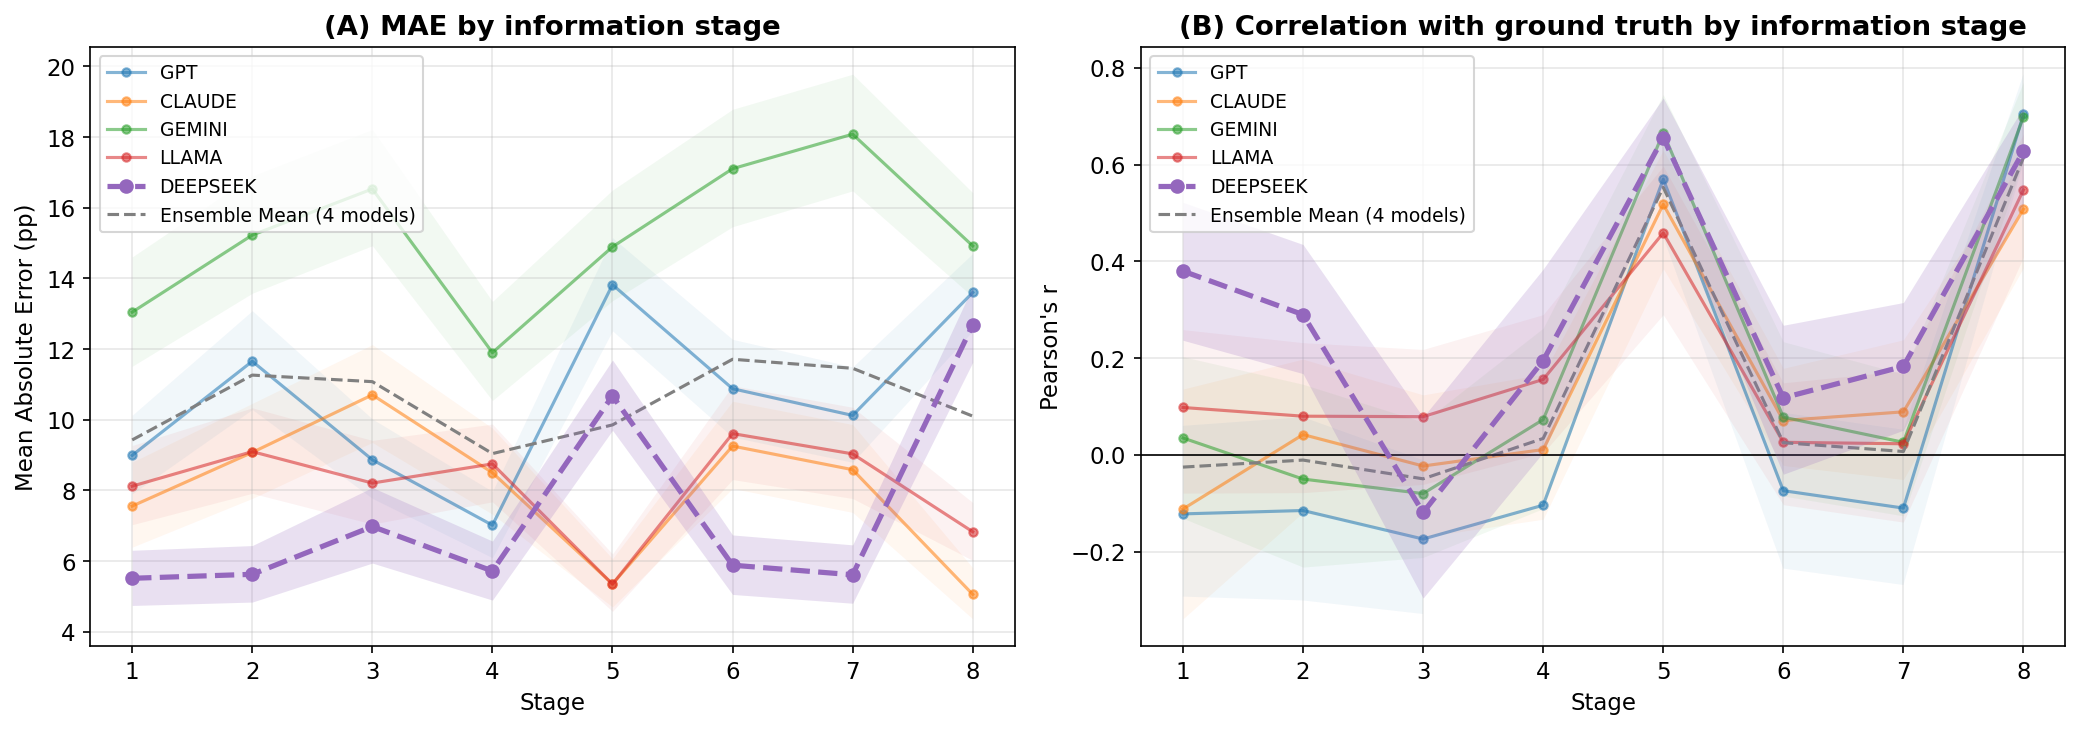

Saved fig_S_deepseek_staged_trajectory.[pdf/png]


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.set_dpi(150)

# "Ensemble Mean" reference line = mean across the four ORIGINAL models only (matches
# Fig. 3's existing definition; DeepSeek is the addition being compared against it, not
# folded into it)
ensemble_mae = trajectory_table[[f"{MODEL_LABELS5[m]} MAE" for m in ["gpt", "claude", "gemini", "llama"]]].mean(axis=1)
ensemble_r = trajectory_table[[f"{MODEL_LABELS5[m]} r" for m in ["gpt", "claude", "gemini", "llama"]]].mean(axis=1)

for m in MODELS5:
    label = MODEL_LABELS5[m]
    x = trajectory_table["Stage"]
    mae, mae_lo, mae_hi = trajectory_table[f"{label} MAE"], trajectory_table[f"{label} MAE lo"], trajectory_table[f"{label} MAE hi"]
    r, r_lo, r_hi = trajectory_table[f"{label} r"], trajectory_table[f"{label} r lo"], trajectory_table[f"{label} r hi"]

    is_ds = (m == "deepseek")
    style = dict(color=MODEL_COLORS5[m], linewidth=2.5 if is_ds else 1.5,
                 marker="o", markersize=6 if is_ds else 4,
                 alpha=1.0 if is_ds else 0.55, zorder=5 if is_ds else 2)
    if is_ds:
        style["linestyle"] = "--"

    band_alpha = 0.20 if is_ds else 0.06

    axes[0].plot(x, mae, label=label, **style)
    axes[0].fill_between(x, mae_lo, mae_hi, color=MODEL_COLORS5[m], alpha=band_alpha, linewidth=0, zorder=5 if is_ds else 1)

    axes[1].plot(x, r, label=label, **style)
    axes[1].fill_between(x, r_lo, r_hi, color=MODEL_COLORS5[m], alpha=band_alpha, linewidth=0, zorder=5 if is_ds else 1)

axes[0].plot(trajectory_table["Stage"], ensemble_mae, color="gray", linestyle="--", linewidth=1.5, label="Ensemble Mean (4 models)")
axes[1].plot(trajectory_table["Stage"], ensemble_r, color="gray", linestyle="--", linewidth=1.5, label="Ensemble Mean (4 models)")
axes[1].axhline(0, color="black", linewidth=0.8)

axes[0].set_xlabel("Stage")
axes[0].set_ylabel("Mean Absolute Error (pp)")
axes[0].set_title("(A) MAE by information stage", fontweight="bold")
axes[0].set_xticks(range(1, N_STAGES + 1))
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="upper left", fontsize=9)

axes[1].set_xlabel("Stage")
axes[1].set_ylabel("Pearson's r")
axes[1].set_title("(B) Correlation with ground truth by information stage", fontweight="bold")
axes[1].set_xticks(range(1, N_STAGES + 1))
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper left", fontsize=9)

fig.tight_layout()
fig.savefig("fig_S_deepseek_staged_trajectory.pdf", dpi=200, bbox_inches="tight")
fig.savefig("fig_S_deepseek_staged_trajectory.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved fig_S_deepseek_staged_trajectory.[pdf/png]")


## 6. Rank metrics and resource-gradient check at Stage 8 (DeepSeek only)

Mirrors Sections 2 and 4 of the main revision-diagnostics notebook, extended to include DeepSeek, so the comparison table can be dropped straight into the same SM table/response letter.

In [19]:
s8_5 = combined[combined["stage"] == 8].copy()

rank_rows = []
for m in MODELS5:
    d = s8_5[[f"pred_{m}", "ground_truth_pi"]].dropna()
    r, _ = pearsonr(d[f"pred_{m}"], d["ground_truth_pi"])
    rho, _ = spearmanr(d[f"pred_{m}"], d["ground_truth_pi"])
    tau, _ = kendalltau(d[f"pred_{m}"], d["ground_truth_pi"])
    mae = (d[f"pred_{m}"] - d["ground_truth_pi"]).abs().mean()
    rank_rows.append({"Model": MODEL_LABELS5[m], "MAE": mae, "Pearson r": r, "Spearman \u03c1": rho, "Kendall \u03c4": tau, "N": len(d)})

rank_table5 = pd.DataFrame(rank_rows).round(3).sort_values("MAE").reset_index(drop=True)
rank_table5.to_csv("rank_metrics_stage8_with_deepseek.csv", index=False)
rank_table5


,Model,MAE,Pearson r,Spearman ρ,Kendall τ,N
0,CLAUDE,5.058,0.508,0.470,0.352,125
1,LLAMA,6.830,0.548,0.519,0.395,125
2,DEEPSEEK,12.685,0.628,0.620,0.467,125
3,GPT,13.603,0.704,0.701,0.561,125
4,GEMINI,14.921,0.699,0.709,0.521,125


In [21]:
# GDP / internet tertile MAE, DeepSeek vs. incumbents (Stage 8) \u2014 requires
# gdp_capita_2021 (in data_final.csv) and internet_usage (from matched_internet_usage.csv,
# merge in if you want the internet-tertile half of this table)
s8_5["gdp_tertile"] = pd.qcut(s8_5["gdp_capita_2021"], 3, labels=["Low", "Mid", "High"])
gdp_tert5 = s8_5.groupby("gdp_tertile", observed=True)[[f"err_{m}" for m in MODELS5]].mean()
gdp_tert5.columns = [MODEL_LABELS5[m] for m in MODELS5]
gdp_tert5.round(2).to_csv("gdp_tertile_mae_stage8_with_deepseek.csv")
print("GDP tertile MAE (Stage 8), all five models:")
gdp_tert5.round(2)


GDP tertile MAE (Stage 8), all five models:


,GPT,CLAUDE,GEMINI,LLAMA,DEEPSEEK
gdp_tertile,,,,,
Low,13.76,4.97,18.32,6.82,13.97
Mid,14.12,4.95,14.31,7.48,12.46
High,12.94,5.25,12.12,6.21,11.61


## 8. Follow-up: T1 direct recall probe (added after Stage 1-8 results)

**Why this was added.** The Stage 1-8 run above showed DeepSeek at r\u22480.38 with *country name only* (Stage 1) \u2014 every other model is at r\u22480 there. That's the one result in this notebook that isn't just "a fifth data point," it's a specific, checkable claim: does DeepSeek know something about country-level climate perception gaps that the other four models don't, from the country name alone? T1 is the cheapest test that bears directly on it (125 calls, not 1,000), so it's worth running before writing this up, rather than reporting the Stage 1 anomaly as an unresolved footnote.

**\u26a0\ufe0f Fidelity note (same caveat as Stages 2-5):** I don't have your notebook 21's exact T1 prompt text saved verbatim \u2014 only the design description and the resulting numbers (Claude: recall MAE 8.02 vs. Stage 8's 5.06 p.p.; Llama: 10.70 vs. 6.83 p.p.). The prompt below is reconstructed from that description: it names Andre et al. (2024, *Nature Climate Change*) explicitly and inverts the anti-recall system prompt to actively invite retrieval, matching the logic of your T1 figure note. **If you have notebook 21, diff this against it before running** \u2014 for a memorization-diagnostic test, exact wording matters more than for the Stage 2-5 reconstructions.

**Logic, unchanged from the main study:** if recall MAE is \u2264 Stage 8 MAE, that's consistent with the model retrieving memorized country-level values. If recall MAE exceeds Stage 1 MAE too (retrieval invited but performs *worse* than retrieval suppressed), that's the strongest evidence against memorization \u2014 the pattern Claude and Llama both showed.

In [ ]:
RECALL_SYSTEM_PROMPT = """You are a research assistant helping to verify survey data. You have access to your training knowledge about published academic research, including climate opinion surveys.

Andre et al. (2024), published in Nature Climate Change, is a study using Gallup World Poll 2021/22 data across 125 countries. It reports, for each country, the percentage of respondents who believed OTHER people in their country would be willing to contribute at least 1% of their household income every month to fight global warming (a second-order belief / perceived-norm estimate).

If you have knowledge of this paper or its reported country-level values, use it. Cite the paper and report the specific value you recall for the country asked about, if you have it.

Response format: Provide ONLY a JSON object containing a single number between 0 and 100 with one decimal place: {"prediction": XX.X}
Do not include any explanation, reasoning, or citation text in your response \u2014 only the JSON. (If you genuinely have no specific recollection of a value for this country, give your best estimate anyway \u2014 do not refuse.)
"""

def build_prompt_recall(row):
    country = row["countrynew"]
    return (
        f"What value did Andre et al. (2024, Nature Climate Change) report for {country} for the percentage of "
        f"respondents who believed OTHER respondents in {country} were willing to contribute at least 1% of "
        f"their household income every month to fight global warming (the second-order belief / perceived-norm "
        f"estimate)? Respond with a single number between 0 and 100, with one decimal place."
    )

print(build_prompt_recall(df.iloc[0]))


In [27]:
RECALL_CHECKPOINT_FILE = "deepseek_recall_probe.csv"

if os.path.exists(RECALL_CHECKPOINT_FILE):
    recall_results = pd.read_csv(RECALL_CHECKPOINT_FILE).to_dict("records")
    recall_done = {r["countrynew"] for r in recall_results}
    print(f"Resuming: {len(recall_done)} countries already completed.")
else:
    recall_results = []
    recall_done = set()
    print("Starting fresh recall-probe run.")

for _, row in df.iterrows():
    country = row["countrynew"]
    if country in recall_done:
        continue
    prompt = build_prompt_recall(row)
    raw = call_deepseek(prompt, system_prompt=RECALL_SYSTEM_PROMPT)
    pred = parse_prediction(raw)
    recall_results.append({"countrynew": country, "pred_deepseek_recall": pred, "raw_response": raw})
    recall_done.add(country)
    if len(recall_done) % 25 == 0:
        pd.DataFrame(recall_results).to_csv(RECALL_CHECKPOINT_FILE, index=False)
        print(f"  checkpoint saved \u2014 {len(recall_done)}/{len(df)} countries complete")

pd.DataFrame(recall_results).to_csv(RECALL_CHECKPOINT_FILE, index=False)
print(f"\nDone. {len(recall_done)}/{len(df)} countries saved to {RECALL_CHECKPOINT_FILE}")


Resuming: 125 countries already completed.

Done. 125/125 countries saved to deepseek_recall_probe.csv


In [29]:
recall = pd.read_csv(RECALL_CHECKPOINT_FILE).merge(gt[["countrynew", "ground_truth_pi"]], on="countrynew", how="left")
recall = recall.dropna(subset=["pred_deepseek_recall", "ground_truth_pi"])
recall_mae = (recall["pred_deepseek_recall"] - recall["ground_truth_pi"]).abs().mean()
recall_r, _ = pearsonr(recall["pred_deepseek_recall"], recall["ground_truth_pi"])

stage1_mae = trajectory_table.loc[trajectory_table["Stage"] == 1, f"{MODEL_LABELS5['deepseek']} MAE"].values[0]
stage8_mae_ds = trajectory_table.loc[trajectory_table["Stage"] == 8, f"{MODEL_LABELS5['deepseek']} MAE"].values[0]

print(f"DeepSeek recall probe:  N={len(recall)}  MAE={recall_mae:.2f} p.p.  r={recall_r:.3f}")
print(f"DeepSeek Stage 1 (retrieval suppressed, country only): MAE={stage1_mae:.2f} p.p.")
print(f"DeepSeek Stage 8 (full information):                  MAE={stage8_mae_ds:.2f} p.p.")
print()
if recall_mae <= stage8_mae_ds:
    print("\u26a0\ufe0f  Recall MAE <= Stage 8 MAE \u2014 consistent with memorization. Needs further investigation (T2-T4 style checks) before reporting Stage 1 as structured inference.")
elif recall_mae > stage1_mae:
    print("\u2713  Recall MAE > Stage 1 MAE \u2014 inviting retrieval performs WORSE than suppressing it. This is the same pattern found for Claude and Llama and argues against memorization as the driver of the Stage 1 anomaly.")
else:
    print("Recall MAE falls between Stage 1 and Stage 8 \u2014 inconclusive; consider a second check (e.g. false-norm injection, T2-style) before drawing a conclusion.")

pd.DataFrame([{
    "Model": "DeepSeek-V3.1",
    "Recall MAE": recall_mae, "Recall r": recall_r,
    "Stage 1 MAE": stage1_mae, "Stage 8 MAE": stage8_mae_ds,
}]).round(3).to_csv("deepseek_recall_probe_summary.csv", index=False)


DeepSeek recall probe:  N=125  MAE=16.78 p.p.  r=0.349
DeepSeek Stage 1 (retrieval suppressed, country only): MAE=5.51 p.p.
DeepSeek Stage 8 (full information):                  MAE=12.69 p.p.

✓  Recall MAE > Stage 1 MAE — inviting retrieval performs WORSE than suppressing it. This is the same pattern found for Claude and Llama and argues against memorization as the driver of the Stage 1 anomaly.


## 9. Bootstrap 95% CIs for the writeup

Matches the convention used elsewhere in the SM (10,000 resamples, country-level resampling with replacement) for: Stage 8 MAE/r, Stage 1 r, and recall-probe MAE/r.

In [31]:
# Reuses bootstrap_mae_r() defined in Section 5 (single implementation, same
# 10,000-resample convention, avoids two slightly-different bootstrap routines
# in the same notebook).

d8 = s8_5.dropna(subset=["pred_deepseek", "ground_truth_pi"])
b8 = bootstrap_mae_r(d8["pred_deepseek"], d8["ground_truth_pi"])

d1 = combined[combined["stage"] == 1].dropna(subset=["pred_deepseek", "ground_truth_pi"])
b1 = bootstrap_mae_r(d1["pred_deepseek"], d1["ground_truth_pi"])

b_rec = bootstrap_mae_r(recall["pred_deepseek_recall"], recall["ground_truth_pi"])

ci_table = pd.DataFrame([
    {"Metric": "Stage 8 MAE", "Estimate": b8["mae"], "95% CI low": b8["mae_lo"], "95% CI high": b8["mae_hi"]},
    {"Metric": "Stage 8 r",   "Estimate": b8["r"],   "95% CI low": b8["r_lo"],   "95% CI high": b8["r_hi"]},
    {"Metric": "Stage 1 r",   "Estimate": b1["r"],   "95% CI low": b1["r_lo"],   "95% CI high": b1["r_hi"]},
    {"Metric": "Recall MAE",  "Estimate": b_rec["mae"], "95% CI low": b_rec["mae_lo"], "95% CI high": b_rec["mae_hi"]},
    {"Metric": "Recall r",    "Estimate": b_rec["r"],   "95% CI low": b_rec["r_lo"],   "95% CI high": b_rec["r_hi"]},
]).round(3)
ci_table.to_csv("deepseek_bootstrap_cis.csv", index=False)
ci_table


,Metric,Estimate,95% CI low,95% CI high
0,Stage 8 MAE,12.685,11.626,13.771
1,Stage 8 r,0.628,0.519,0.719
2,Stage 1 r,0.380,0.237,0.522
3,Recall MAE,16.782,15.330,18.223
4,Recall r,0.349,0.188,0.504


## 7. Output summary

All files below are ready to drop into the SM as a new figure/table pair, with one Discussion sentence and one Limitations sentence (see chat) noting this is a single non-Western-developed model, not a systematic test of training-provenance effects.

In [33]:
import os as _os
print("Output files:")
for f in sorted(_os.listdir(".")):
    if f.startswith("deepseek") or f.startswith("fig_S_deepseek") or f.startswith("rank_metrics_stage8_with") or f.startswith("gdp_tertile_mae_stage8_with"):
        print(" -", f)


Output files:
 - deepseek_bootstrap_cis.csv
 - deepseek_predictions_all_stages.csv
 - deepseek_recall_probe.csv
 - deepseek_recall_probe_summary.csv
 - deepseek_staged_trajectory.csv
 - fig_S_deepseek_staged_trajectory.pdf
 - fig_S_deepseek_staged_trajectory.png
 - gdp_tertile_mae_stage8_with_deepseek.csv
 - rank_metrics_stage8_with_deepseek.csv


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=06a315a8-e52a-4232-801d-6bf83a4fef34' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>